# Vector Space Models, TF–IDF, Sparsity, Baselines


1. Represent text as vectors  
2. Weight terms with TF–IDF  
3. Measure similarity in vector space  
4. Build strong baselines  
5. Evaluate properly  
6. Do error analysis like a researcher


**representation → model → evaluation → diagnosis**

By the end of the session, students should be able to answer:

- How do we turn a document into a vector?
- Why is TF–IDF often stronger than raw counts?
- Why do we start with baselines?
- What kinds of errors does a count-based model make?

## Setup

Run this once at the beginning.

In [ ]:
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 120)

## 1. Vocabulary and one-hot

One-hot is mainly a **word-level** idea.  
It helps us understand **vocabulary indexing** and **dimensionality**.

Example vocabulary:

`["dog", "cat", "barks", "runs"]`

Example token:

`dog → [1, 0, 0, 0]`

In [ ]:
vocab = ["dog", "cat", "barks", "runs"]

def one_hot(token, vocabulary):
    vec = np.zeros(len(vocabulary), dtype=int)
    if token in vocabulary:
        vec[vocabulary.index(token)] = 1
    return vec

for token in ["dog", "runs", "cat"]:
    print(f"{token:>5} -> {one_hot(token, vocab)}")

  dog -> [1 0 0 0]
 runs -> [0 0 0 1]
  cat -> [0 1 0 0]


## Document representations

For whole documents, one-hot is not enough.

We usually care about:

- **binary Bag-of-Words**: presence or absence
- **count vectors**: how many times a term occurs
- **TF–IDF**: frequency adjusted by rarity across the corpus

## 2. Binary vs count Bag-of-Words

Sentence:

`dog dog barks`

**Binary representation** only cares whether a word appears.  
**Count representation** cares how many times it appears.

Both ignore word order.

In [ ]:
toy_docs = ["dog dog barks", "cat runs", "dog runs runs"]

binary_vectorizer = CountVectorizer(binary=True)
count_vectorizer = CountVectorizer(binary=False)

binary_X = binary_vectorizer.fit_transform(toy_docs)
count_X = count_vectorizer.fit_transform(toy_docs)

binary_df = pd.DataFrame(binary_X.toarray(), columns=binary_vectorizer.get_feature_names_out())
count_df = pd.DataFrame(count_X.toarray(), columns=count_vectorizer.get_feature_names_out())

print("Binary Bag-of-Words")
display(binary_df)

print("Count Bag-of-Words")
display(count_df)

Binary Bag-of-Words


,barks,cat,dog,runs
0,1,0,1,0
1,0,1,0,1
2,0,0,1,1


Count Bag-of-Words


,barks,cat,dog,runs
0,1,0,2,0
1,0,1,0,1
2,0,0,1,2


## What is missing?

Suppose a corpus contains these documents:

- `dog barks loudly`
- `dog runs fast`
- `dog eats food`

The term **dog** appears everywhere.

That means it is real language, but often weak evidence.

We need a weighting scheme that says:

- frequent **inside** a document can matter
- frequent **everywhere** should count less

That is the intuition of **TF–IDF**.

## 3. Tiny document–term matrix

Before TF–IDF, it helps to see the raw matrix.

In [18]:
tiny_docs = [
    "dog barks loudly",
    "dog runs fast",
    "dog eats food",
]

tiny_vec = CountVectorizer()
tiny_X = tiny_vec.fit_transform(tiny_docs)

tiny_df = pd.DataFrame(
    tiny_X.toarray(),
    columns=tiny_vec.get_feature_names_out(),
    index=[f"doc{i+1}" for i in range(len(tiny_docs))]
)
display(tiny_df)

,barks,dog,eats,fast,food,loudly,runs
doc1,1,1,0,0,0,1,0
doc2,0,1,0,1,0,0,1
doc3,0,1,1,0,1,0,0


## 4. TF–IDF intuition

Two questions:

- **TF**: how important is the term inside this document?
- **IDF**: how rare is the term across the whole corpus?

A term gets a high TF–IDF score when it is:

- frequent in this document
- not frequent across all documents

That is why words like **the**, **is**, **good** often get downweighted, while more distinctive words get boosted.

## Tiny TF–IDF example, step by step

We use three short documents:

- **doc1**: `movie was great great acting`
- **doc2**: `movie was boring slow`
- **doc3**: `acting was subtle and moving`

We will compute:

1. **TF**: how often each word occurs in each document  
2. **DF**: in how many documents each word appears  
3. **IDF**: how rare the word is across the corpus  
4. **TF–IDF**: TF × IDF

Watch what happens to:
- **was** — common everywhere, so not useful
- **great** — repeated in doc1 and rare overall, so very useful
- **acting** — appears in doc1 and doc3, so moderately useful

In [19]:
mini_docs = {
    "doc1": "movie was great great acting",
    "doc2": "movie was boring slow",
    "doc3": "acting was subtle and moving",
}

tokens_by_doc = {name: text.split() for name, text in mini_docs.items()}
vocab = sorted(set(word for tokens in tokens_by_doc.values() for word in tokens))
N = len(mini_docs)

rows = []
for term in vocab:
    df = sum(term in tokens for tokens in tokens_by_doc.values())
    idf = math.log(N / df)
    row = {"term": term, "df": df, "idf": round(idf, 3)}
    for doc_name, tokens in tokens_by_doc.items():
        tf = tokens.count(term)
        tfidf = tf * idf
        row[f"tf_{doc_name}"] = tf
        row[f"tfidf_{doc_name}"] = round(tfidf, 3)
    rows.append(row)

tfidf_demo_df = pd.DataFrame(rows).sort_values(["df", "term"])
display(tfidf_demo_df)

,term,df,idf,tf_doc1,tfidf_doc1,tf_doc2,tfidf_doc2,tf_doc3,tfidf_doc3
1,and,1,1.099,0,0.000,0,0.000,1,1.099
2,boring,1,1.099,0,0.000,1,1.099,0,0.000
3,great,1,1.099,2,2.197,0,0.000,0,0.000
5,moving,1,1.099,0,0.000,0,0.000,1,1.099
6,slow,1,1.099,0,0.000,1,1.099,0,0.000
7,subtle,1,1.099,0,0.000,0,0.000,1,1.099
0,acting,2,0.405,1,0.405,0,0.000,1,0.405
4,movie,2,0.405,1,0.405,1,0.405,0,0.000
8,was,3,0.000,1,0.000,1,0.000,1,0.000


## 5. TF–IDF in practice

Now let the vectoriser do the work.

In [20]:
tfidf_vec = TfidfVectorizer()
tfidf_X = tfidf_vec.fit_transform(list(mini_docs.values()))

tfidf_df = pd.DataFrame(
    tfidf_X.toarray(),
    index=list(mini_docs.keys()),
    columns=tfidf_vec.get_feature_names_out()
).round(3)

display(tfidf_df)

,acting,and,boring,great,movie,moving,slow,subtle,was
doc1,0.324,0.000,0.000,0.852,0.324,0.000,0.000,0.000,0.252
doc2,0.000,0.000,0.584,0.000,0.445,0.000,0.584,0.000,0.345
doc3,0.384,0.505,0.000,0.000,0.000,0.505,0.000,0.505,0.298


## 6. The vector space idea

Once documents become vectors, we can compare them.

This matters for **IR** as well as classification.

We can compute:

- query ↔ document similarity
- document ↔ document similarity

A simple similarity measure is **cosine similarity**.

In [21]:
query = ["great acting movie"]
query_vec = tfidf_vec.transform(query)

doc_names = list(mini_docs.keys())
similarities = cosine_similarity(query_vec, tfidf_X).flatten()

similarity_df = pd.DataFrame({
    "document": doc_names,
    "text": list(mini_docs.values()),
    "cosine_similarity_to_query": similarities
}).sort_values("cosine_similarity_to_query", ascending=False)

display(similarity_df)

,document,text,cosine_similarity_to_query
0,doc1,movie was great great acting,0.916091
1,doc2,movie was boring slow,0.230194
2,doc3,acting was subtle and moving,0.198738


## Discussion prompt

Why is **doc1** closest to the query?

Because vector-space models capture weighted term overlap.

This is the conceptual bridge:

- vector representations are useful for **retrieval**
- the same representations can later feed **classifiers**

## 7. Sparsity

Real vocabularies are large.  
Any single document uses only a tiny fraction of all possible terms.

So most entries in the matrix are **zero**.

That is why count-based document representations are called **sparse**.

In [22]:
more_docs = [
    "neural models work well on language tasks",
    "bm25 remains a powerful baseline for retrieval",
    "tf idf is sparse but interpretable",
    "transformers provide dense contextual representations",
    "error analysis reveals model weaknesses",
    "logistic regression is simple fast and strong",
    "preprocessing choices affect downstream performance",
    "documents become vectors in the vector space model",
] * 20

sparse_vec = TfidfVectorizer(ngram_range=(1, 2))
sparse_X = sparse_vec.fit_transform(more_docs)

rows, cols = sparse_X.shape
nnz = sparse_X.nnz
density = nnz / (rows * cols)

print(f"Shape: {rows} rows × {cols} columns")
print(f"Non-zero entries: {nnz}")
print(f"Density: {density:.4f}")
print(f"Sparsity: {1-density:.4f}")

Shape: 160 rows × 88 columns
Non-zero entries: 1800
Density: 0.1278
Sparsity: 0.8722


## Why sparsity matters

Advantages:

- memory efficient
- fast to train
- easy to interpret
- strong baseline for many tasks

Limits:

- ignores word order
- weak semantics
- brittle under paraphrase
- struggles with subtle context

That is why embeddings matter later.  
But we do **not** skip strong baselines.

## 8. Why baselines matter

A baseline is not a ritual.  
It is a **reference point**.

Today we will compare **three systems**:

1. **Dummy majority baseline**
2. **CountVectorizer + Logistic Regression**
3. **TfidfVectorizer + Logistic Regression**

Without comparison, a score is just a number.

## Main lab dataset

We use a **small self-contained sentiment dataset** so the notebook runs anywhere.

This is deliberate:

- no downloads
- no API keys
- no hidden preprocessing
- everything visible in class

In [23]:
data = [
    ("I loved the film and the performances were excellent", "pos"),
    ("A warm funny and moving story", "pos"),
    ("The acting was sharp and the script was thoughtful", "pos"),
    ("Beautiful cinematography and a strong ending", "pos"),
    ("Smart writing and memorable characters", "pos"),
    ("I expected little but this was genuinely good", "pos"),
    ("Tense engaging and very well directed", "pos"),
    ("A delightful film with emotional depth", "pos"),
    ("The soundtrack was lovely and the pacing worked", "pos"),
    ("Surprisingly charming and consistently entertaining", "pos"),
    ("A clever script with strong dialogue", "pos"),
    ("This was one of the better films I watched this month", "pos"),
    ("Confident direction and a satisfying conclusion", "pos"),
    ("Funny without becoming silly", "pos"),
    ("The cast worked brilliantly together", "pos"),
    ("A thoughtful and rewarding watch", "pos"),
    ("The story was simple but beautifully told", "pos"),
    ("I would gladly watch it again", "pos"),
    ("The lead performance carried the film well", "pos"),
    ("Inventive warm and emotionally honest", "pos"),
    ("What a joy this film turned out to be", "pos"),
    ("Rich atmosphere and very good acting", "pos"),
    ("This was engaging from beginning to end", "pos"),
    ("A satisfying drama with real feeling", "pos"),
    ("The humour landed and the characters felt real", "pos"),
    ("Technically polished and narratively strong", "pos"),
    ("Much better than I expected", "pos"),
    ("The final act was excellent", "pos"),
    ("Good performances and strong emotional payoff", "pos"),
    ("A genuinely enjoyable experience", "pos"),
    ("I hated the film and the writing was lazy", "neg"),
    ("A dull and forgettable story", "neg"),
    ("The acting was flat and the dialogue was weak", "neg"),
    ("Predictable from start to finish", "neg"),
    ("The pacing was awful and the ending was worse", "neg"),
    ("I kept waiting for it to improve but it never did", "neg"),
    ("Confused direction and lifeless characters", "neg"),
    ("Too long too loud and not interesting", "neg"),
    ("The jokes were stale and badly timed", "neg"),
    ("A disappointing and messy film", "neg"),
    ("This was painfully boring", "neg"),
    ("A shallow script with no emotional impact", "neg"),
    ("The plot made little sense", "neg"),
    ("The cast tried but the material was poor", "neg"),
    ("It looked expensive but felt empty", "neg"),
    ("I would not recommend this to anyone", "neg"),
    ("The trailer promised more than the film delivered", "neg"),
    ("An unfocused film with weak performances", "neg"),
    ("The editing was chaotic", "neg"),
    ("Nothing here felt fresh or convincing", "neg"),
    ("A weak ending ruined what little interest remained", "neg"),
    ("The dialogue sounded unnatural", "neg"),
    ("This was tedious and badly written", "neg"),
    ("The film takes itself seriously and still fails", "neg"),
    ("Overlong underwritten and emotionally flat", "neg"),
    ("I regret spending time on this", "neg"),
    ("The performances could not save the script", "neg"),
    ("A forgettable and frustrating watch", "neg"),
    ("This was not good at all", "neg"),
    ("The story collapsed in the second half", "neg"),
    ("I thought this would be terrible but it was actually good", "pos"),
    ("Not perfect but still worth watching", "pos"),
    ("The first half was weak yet the ending rescued it", "pos"),
    ("I was ready to hate it and then it won me over", "pos"),
    ("It is slow in places but the performances are excellent", "pos"),
    ("The film is not boring once it finds its rhythm", "pos"),
    ("I did not expect to enjoy this as much as I did", "pos"),
    ("The story is strange but strangely moving", "pos"),
    ("It tries very hard to be profound and fails", "neg"),
    ("Not even the good cast could make this work", "neg"),
    ("I wanted to like it but the script kept getting worse", "neg"),
    ("The visuals are nice but the film is still empty", "neg"),
    ("It is not terrible but it is not interesting either", "neg"),
    ("I laughed once and then checked the time", "neg"),
    ("The film thinks it is clever and that becomes exhausting", "neg"),
    ("The idea is good on paper but the execution is poor", "neg"),
]

df = pd.DataFrame(data, columns=["text", "label"])
display(df.sample(8, random_state=RANDOM_STATE))
print(df["label"].value_counts())

,text,label
4,Smart writing and memorable characters,pos
35,I kept waiting for it to improve but it never did,neg
10,A clever script with strong dialogue,pos
0,I loved the film and the performances were excellent,pos
45,I would not recommend this to anyone,neg
47,An unfocused film with weak performances,neg
65,The film is not boring once it finds its rhythm,pos
53,The film takes itself seriously and still fails,neg


label
pos    38
neg    38
Name: count, dtype: int64


## 9. Train/test split

We keep the split simple and stratified.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print(pd.Series(y_train).value_counts())

Train size: 57
Test size:  19
label
pos    29
neg    28
Name: count, dtype: int64


## 10. Baseline 1 — Dummy majority classifier

This gives us a floor.

If a “real” model does not beat this clearly, something is wrong.

In [26]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train.to_frame(), y_train)
dummy_pred = dummy.predict(X_test.to_frame())

dummy_acc = accuracy_score(y_test, dummy_pred)
dummy_f1 = f1_score(y_test, dummy_pred, average="macro")

print("Dummy majority baseline")
print(f"Accuracy: {dummy_acc:.3f}")
print(f"Macro F1: {dummy_f1:.3f}")
print(classification_report(y_test, dummy_pred))

Dummy majority baseline
Accuracy: 0.474
Macro F1: 0.321
              precision    recall  f1-score   support

         neg       0.00      0.00      0.00        10
         pos       0.47      1.00      0.64         9

    accuracy                           0.47        19
   macro avg       0.24      0.50      0.32        19
weighted avg       0.22      0.47      0.30        19



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 11. Baseline 2 — CountVectorizer + Logistic Regression

This is our first real count-based baseline.

In [27]:
count_clf = Pipeline([
    ("vec", CountVectorizer()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

count_clf.fit(X_train, y_train)
count_pred = count_clf.predict(X_test)

count_acc = accuracy_score(y_test, count_pred)
count_f1 = f1_score(y_test, count_pred, average="macro")

print("CountVectorizer + Logistic Regression")
print(f"Accuracy: {count_acc:.3f}")
print(f"Macro F1: {count_f1:.3f}")
print(classification_report(y_test, count_pred))

CountVectorizer + Logistic Regression
Accuracy: 0.368
Macro F1: 0.321
              precision    recall  f1-score   support

         neg       0.25      0.10      0.14        10
         pos       0.40      0.67      0.50         9

    accuracy                           0.37        19
   macro avg       0.33      0.38      0.32        19
weighted avg       0.32      0.37      0.31        19



## 12. Baseline 3 — TfidfVectorizer + Logistic Regression

This is usually the strongest count-based baseline in an introductory session.

In [28]:
tfidf_clf = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
])

tfidf_clf.fit(X_train, y_train)
tfidf_pred = tfidf_clf.predict(X_test)

tfidf_acc = accuracy_score(y_test, tfidf_pred)
tfidf_f1 = f1_score(y_test, tfidf_pred, average="macro")

print("TfidfVectorizer + Logistic Regression")
print(f"Accuracy: {tfidf_acc:.3f}")
print(f"Macro F1: {tfidf_f1:.3f}")
print(classification_report(y_test, tfidf_pred))

TfidfVectorizer + Logistic Regression
Accuracy: 0.474
Macro F1: 0.472
              precision    recall  f1-score   support

         neg       0.50      0.40      0.44        10
         pos       0.45      0.56      0.50         9

    accuracy                           0.47        19
   macro avg       0.48      0.48      0.47        19
weighted avg       0.48      0.47      0.47        19



## 13. Compare the baselines

Now the numbers mean something because they are relative to alternatives.

In [29]:
results = pd.DataFrame({
    "model": [
        "Dummy majority",
        "CountVectorizer + Logistic Regression",
        "TfidfVectorizer + Logistic Regression",
    ],
    "accuracy": [dummy_acc, count_acc, tfidf_acc],
    "macro_f1": [dummy_f1, count_f1, tfidf_f1],
}).sort_values(["macro_f1", "accuracy"], ascending=False)

display(results.style.format({"accuracy": "{:.3f}", "macro_f1": "{:.3f}"}))

,model,accuracy,macro_f1
2,TfidfVectorizer + Logistic Regression,0.474,0.472
0,Dummy majority,0.474,0.321
1,CountVectorizer + Logistic Regression,0.368,0.321


## 14. Confusion matrix

Accuracy is not enough.

We also want to see **what kinds of mistakes** the model makes.

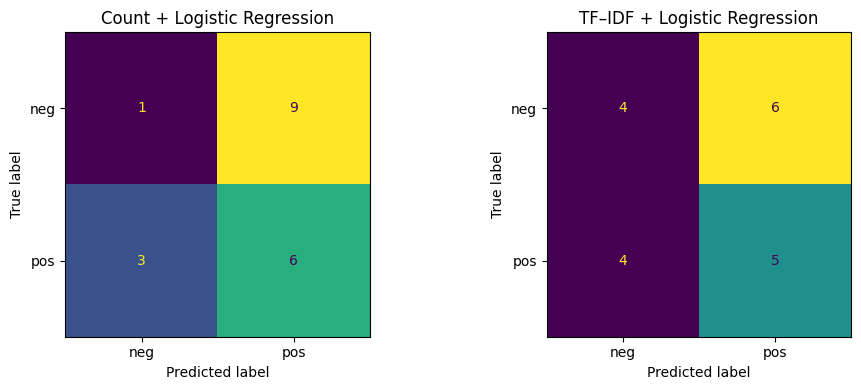

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, count_pred, ax=axes[0], colorbar=False
)
axes[0].set_title("Count + Logistic Regression")

ConfusionMatrixDisplay.from_predictions(
    y_test, tfidf_pred, ax=axes[1], colorbar=False
)
axes[1].set_title("TF–IDF + Logistic Regression")

plt.tight_layout()
plt.show()

## 15. Inspect the model

Logistic regression is pedagogically useful because it is interpretable.

We can ask:

- which words push prediction toward **positive**?
- which words push prediction toward **negative**?

That is the start of model interpretation.

In [ ]:
def show_top_features(pipeline, n=12):
    vec = pipeline.named_steps["vec"]
    clf = pipeline.named_steps["clf"]
    feature_names = np.array(vec.get_feature_names_out())
    coefs = clf.coef_[0]

    top_pos_idx = np.argsort(coefs)[-n:][::-1]
    top_neg_idx = np.argsort(coefs)[:n]

    pos_df = pd.DataFrame({
        "feature": feature_names[top_pos_idx],
        "weight_toward_pos": coefs[top_pos_idx]
    })

    neg_df = pd.DataFrame({
        "feature": feature_names[top_neg_idx],
        "weight_toward_pos": coefs[top_neg_idx]
    })

    return pos_df, neg_df

pos_df, neg_df = show_top_features(tfidf_clf, n=12)

print("Top positive features")
display(pos_df)

print("Top negative features")
display(neg_df)

## 16. Error analysis

A researcher does not stop at the score.

A researcher asks:

- Which examples failed?
- Why did they fail?
- What pattern do the failures reveal?
- What change might fix them?

In [33]:
error_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "pred_count": count_pred,
    "pred_tfidf": tfidf_pred,
})

error_df["count_correct"] = error_df["true_label"] == error_df["pred_count"]
error_df["tfidf_correct"] = error_df["true_label"] == error_df["pred_tfidf"]

print("Errors made by TF–IDF model")
display(error_df.loc[~error_df["tfidf_correct"], ["text", "true_label", "pred_tfidf"]])

print("Errors made by Count model")
display(error_df.loc[~error_df["count_correct"], ["text", "true_label", "pred_count"]])

Errors made by TF–IDF model


,text,true_label,pred_tfidf
1,The soundtrack was lovely and the pacing worked,pos,neg
4,This was painfully boring,neg,pos
5,What a joy this film turned out to be,pos,neg
6,Too long too loud and not interesting,neg,pos
7,It is slow in places but the performances are excellent,pos,neg
12,This was not good at all,neg,pos
14,It is not terrible but it is not interesting either,neg,pos
15,Not even the good cast could make this work,neg,pos
16,The humour landed and the characters felt real,pos,neg
18,This was tedious and badly written,neg,pos


Errors made by Count model


,text,true_label,pred_count
1,The soundtrack was lovely and the pacing worked,pos,neg
3,The editing was chaotic,neg,pos
4,This was painfully boring,neg,pos
5,What a joy this film turned out to be,pos,neg
6,Too long too loud and not interesting,neg,pos
9,It looked expensive but felt empty,neg,pos
11,A weak ending ruined what little interest remained,neg,pos
12,This was not good at all,neg,pos
14,It is not terrible but it is not interesting either,neg,pos
15,Not even the good cast could make this work,neg,pos


## Structured error-analysis worksheet

For each wrong prediction, fill in:

- **text**
- **true label**
- **predicted label**
- **likely trigger words**
- **failure type**
- **possible fix**

Useful failure types:

- negation
- sarcasm or irony
- ambiguous wording
- weak context
- misleading strong word
- label noise
- domain mismatch
- preprocessing issue

In [32]:
proba = tfidf_clf.predict_proba(X_test)
classes = tfidf_clf.named_steps["clf"].classes_

proba_df = pd.DataFrame(proba, columns=[f"p_{c}" for c in classes])
analysis_df = pd.concat(
    [
        X_test.reset_index(drop=True).rename("text"),
        y_test.reset_index(drop=True).rename("true_label"),
        pd.Series(tfidf_pred, name="predicted_label"),
        proba_df,
    ],
    axis=1,
)

display(analysis_df.sort_values("p_pos").head(8))
display(analysis_df.sort_values("p_pos", ascending=False).head(8))

,text,true_label,predicted_label,p_neg,p_pos
2,The film takes itself seriously and still fails,neg,neg,0.567827,0.432173
16,The humour landed and the characters felt real,pos,neg,0.558584,0.441416
1,The soundtrack was lovely and the pacing worked,pos,neg,0.538534,0.461466
3,The editing was chaotic,neg,neg,0.533305,0.466695
7,It is slow in places but the performances are excellent,pos,neg,0.528768,0.471232
9,It looked expensive but felt empty,neg,neg,0.518788,0.481212
11,A weak ending ruined what little interest remained,neg,neg,0.508038,0.491962
5,What a joy this film turned out to be,pos,neg,0.500790,0.499210


,text,true_label,predicted_label,p_neg,p_pos
12,This was not good at all,neg,pos,0.359454,0.640546
4,This was painfully boring,neg,pos,0.383630,0.616370
17,Beautiful cinematography and a strong ending,pos,pos,0.401138,0.598862
13,Tense engaging and very well directed,pos,pos,0.423846,0.576154
10,Funny without becoming silly,pos,pos,0.429665,0.570335
18,This was tedious and badly written,neg,pos,0.453116,0.546884
0,The final act was excellent,pos,pos,0.462925,0.537075
15,Not even the good cast could make this work,neg,pos,0.467913,0.532087


## Closing line

**Count-based vectors are the baseline we must beat, not the past we can ignore.**